# Associative Recall: Attention Evolution Analysis

Trains both models like `train.ipynb`, but additionally:

- checkpoints each model's weights every `checkpoint_every` steps,
- stops early once eval accuracy reaches `early_stop_acc`,
- and, for a fixed example sequence, replays every checkpoint to plot how the QK attention
  heatmap (per layer, averaged over heads) evolves over the course of training -- this is
  where you can actually *see* the induction-head circuit ("attend back to a previous
  occurrence of this key, read off what followed it") assemble itself.

Note: `early_stop_acc=1.0` means *exact* 100% on the eval batch, which can be a strict bar at
`eval_batch_size=512` (one mistake in 4096 recall predictions keeps it from triggering) --
lower it slightly (e.g. 0.999) if it never fires.

In [56]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch

from data import generate_batch, key_position_mask, seq_len, vocab_size
from models import SpikingTransformer, VanillaTransformer
from train import compute_loss_and_acc, pick_device, plot_comparison, train_one_model


## Config

In [ ]:
num_kv_pairs = 3
num_rounds = 2
num_keys = 32
num_values = 32

dim = 128
depth = 2
num_heads = 1
T = 10  # spiking simulation time steps

batch_size = 64
eval_batch_size = 512
steps = 15000
eval_every = 20
checkpoint_every = 20
early_stop_acc = 0.99
lr = 3e-3
seed = 0

torch.manual_seed(seed)
device = pick_device()

V = vocab_size(num_keys, num_values)
L = seq_len(num_kv_pairs, num_rounds)
mask = key_position_mask(num_kv_pairs, num_rounds, device=device)
print(f"device={device}, vocab_size={V}, seq_len={L}, num_kv_pairs={num_kv_pairs}, num_rounds={num_rounds}")


device=mps, vocab_size=64, seq_len=32, num_kv_pairs=8, num_rounds=2


## Models

In [58]:
vanilla = VanillaTransformer(V, dim=dim, depth=depth, num_heads=num_heads, max_len=L).to(device)
spiking = SpikingTransformer(V, dim=dim, depth=depth, num_heads=num_heads, T=T, max_len=L).to(device)

print(f"VanillaTransformer params: {sum(p.numel() for p in vanilla.parameters()):,}")
print(f"SpikingTransformer params: {sum(p.numel() for p in spiking.parameters()):,}")


VanillaTransformer params: 417,088
SpikingTransformer params: 420,160


## Training

Checkpoints every `checkpoint_every` steps (kept on CPU) and stops early at `early_stop_acc`.

In [59]:
hist_vanilla = train_one_model(
    "vanilla", vanilla, mask, device,
    num_kv_pairs=num_kv_pairs, num_rounds=num_rounds,
    num_keys=num_keys, num_values=num_values,
    batch_size=batch_size, eval_batch_size=eval_batch_size,
    steps=steps, eval_every=eval_every, lr=lr,
    checkpoint_every=checkpoint_every, early_stop_acc=early_stop_acc,
)


[vanilla] step    20 | eval loss 3.3897 | eval acc   9.6% | 0.7s
[vanilla] step    40 | eval loss 3.2621 | eval acc  13.9% | 1.1s
[vanilla] step    60 | eval loss 3.1881 | eval acc  13.3% | 1.4s
[vanilla] step    80 | eval loss 3.0887 | eval acc  13.5% | 1.7s
[vanilla] step   100 | eval loss 2.9475 | eval acc  14.9% | 2.0s
[vanilla] step   120 | eval loss 2.7274 | eval acc  15.9% | 2.3s
[vanilla] step   140 | eval loss 2.4734 | eval acc  20.8% | 2.6s
[vanilla] step   160 | eval loss 1.7852 | eval acc  48.0% | 3.0s
[vanilla] step   180 | eval loss 0.0673 | eval acc  99.2% | 3.3s
[vanilla] early stop at step 180: eval acc 99.2% >= 99.0%


In [60]:
hist_spiking = train_one_model(
    "spiking", spiking, mask, device,
    num_kv_pairs=num_kv_pairs, num_rounds=num_rounds,
    num_keys=num_keys, num_values=num_values,
    batch_size=batch_size, eval_batch_size=eval_batch_size,
    steps=steps, eval_every=eval_every, lr=lr,
    checkpoint_every=checkpoint_every, early_stop_acc=early_stop_acc,
)


[spiking] step    20 | eval loss 3.4438 | eval acc   6.0% | 5.2s
[spiking] step    40 | eval loss 3.2158 | eval acc  12.1% | 10.4s
[spiking] step    60 | eval loss 2.8905 | eval acc  17.9% | 15.5s
[spiking] step    80 | eval loss 2.6121 | eval acc  20.3% | 20.7s
[spiking] step   100 | eval loss 2.4730 | eval acc  20.0% | 25.8s
[spiking] step   120 | eval loss 2.4073 | eval acc  20.3% | 31.5s
[spiking] step   140 | eval loss 2.3486 | eval acc  21.7% | 37.3s
[spiking] step   160 | eval loss 2.0988 | eval acc  29.2% | 43.1s
[spiking] step   180 | eval loss 1.4053 | eval acc  55.2% | 49.0s
[spiking] step   200 | eval loss 0.8042 | eval acc  74.7% | 54.7s
[spiking] step   220 | eval loss 0.4579 | eval acc  85.2% | 59.9s
[spiking] step   240 | eval loss 0.2684 | eval acc  91.1% | 65.5s
[spiking] step   260 | eval loss 0.1785 | eval acc  94.0% | 71.2s
[spiking] step   280 | eval loss 0.1135 | eval acc  96.6% | 76.6s
[spiking] step   300 | eval loss 0.0654 | eval acc  98.4% | 81.9s
[spiking] s

## Results

In [61]:
print("=== Final comparison ===")
print(f"VanillaTransformer  final eval acc: {hist_vanilla['acc'][-1]*100:.1f}% "
      f"({len(hist_vanilla['checkpoints'])} checkpoints)")
print(f"SpikingTransformer  final eval acc: {hist_spiking['acc'][-1]*100:.1f}% "
      f"({len(hist_spiking['checkpoints'])} checkpoints)")


=== Final comparison ===
VanillaTransformer  final eval acc: 99.2% (9 checkpoints)
SpikingTransformer  final eval acc: 99.1% (17 checkpoints)


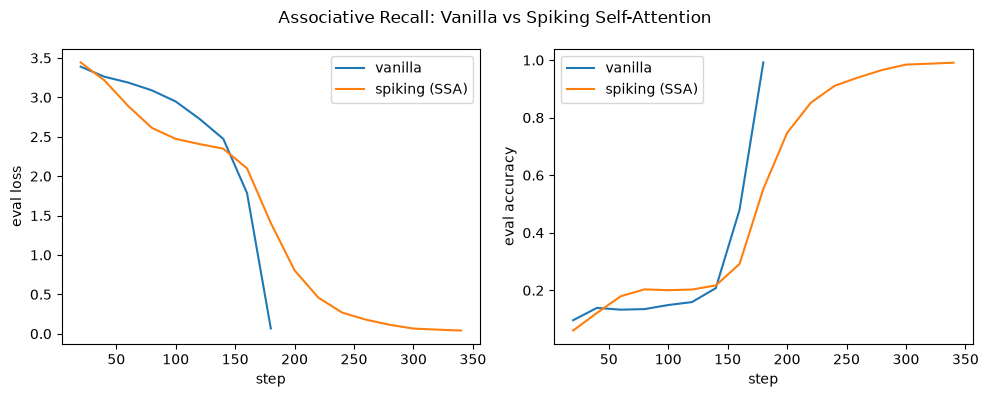

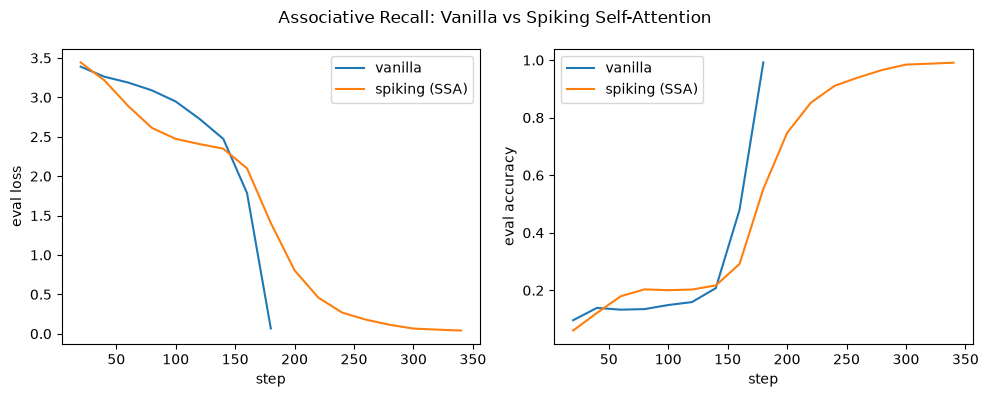

In [62]:
fig = plot_comparison(hist_vanilla, hist_spiking)
fig


## Attention heatmap evolution

For a fixed example sequence, reload each checkpoint's weights, run a forward pass with
`return_attn=True`, and plot the resulting (head-averaged) QK attention matrix per layer.
Dashed lines mark the boundary between round 1 and round 2. Watch for a bright
off-diagonal band appearing at `(query_position, matching_key_position)` pairs as training
progresses -- that's the induction-head lookup forming.

In [63]:
def checkpoint_attn_grid(model, checkpoints, seq, title, max_cols=8):
    """Plot a [layer x checkpoint] grid of head-max attention heatmaps.

    Each cell is the max (not mean) over heads, so a position lights up if
    *any* head attends there. Axis ticks are labeled with the actual input token id at each position
    (bottom row / left column only, to keep it legible), so you can read off
    exactly which (key, value, query) tokens the bright cells connect.

    Temporarily loads each checkpoint's weights into `model` to run the forward
    pass, then restores the model's original (final-trained) weights before
    returning.
    """
    original_state = copy.deepcopy(model.state_dict())
    tokens = seq[0].cpu().tolist()
    L = len(tokens)

    idxs = list(range(len(checkpoints)))
    if len(idxs) > max_cols:
        idxs = sorted(set(np.linspace(0, len(idxs) - 1, max_cols).round().astype(int).tolist()))

    fig, axes = None, None
    for col, i in enumerate(idxs):
        step, state = checkpoints[i]
        model.load_state_dict(state)
        model.eval()
        with torch.no_grad():
            _, attn_maps = model(seq, return_attn=True)

        depth = len(attn_maps)
        if fig is None:
            fig, axes = plt.subplots(depth, len(idxs), figsize=(2.6 * len(idxs), 2.8 * depth), squeeze=False)

        for layer in range(depth):
            mat = attn_maps[layer][0].amax(0).float().cpu().numpy()  # max over heads -> (L, L)
            ax = axes[layer][col]
            ax.imshow(mat, cmap="viridis", aspect="auto")
            ax.axvline(2 * num_kv_pairs - 0.5, color="white", linewidth=0.8, linestyle="--")
            ax.axhline(2 * num_kv_pairs - 0.5, color="white", linewidth=0.8, linestyle="--")

            ax.set_xticks(range(L))
            ax.set_yticks(range(L))
            ax.set_xticklabels(tokens if layer == depth - 1 else [], fontsize=5, rotation=90)
            ax.set_yticklabels(tokens if col == 0 else [], fontsize=5)
            ax.tick_params(length=2)

            if layer == 0:
                ax.set_title(f"step {step}", fontsize=9)
            if col == 0:
                ax.set_ylabel(f"layer {layer}", fontsize=9)

    fig.suptitle(f"{title}\n(tick labels = input token id at each position)")
    fig.tight_layout()
    model.load_state_dict(original_state)
    return fig


In [64]:
example_seq = generate_batch(1, num_kv_pairs, num_rounds, num_keys, num_values, device=device)
print("example_seq:", example_seq.tolist())


example_seq: [[30, 49, 24, 32, 12, 53, 22, 63, 31, 52, 26, 58, 7, 50, 10, 54, 12, 53, 26, 58, 24, 32, 22, 63, 30, 49, 31, 52, 10, 54, 7, 50]]


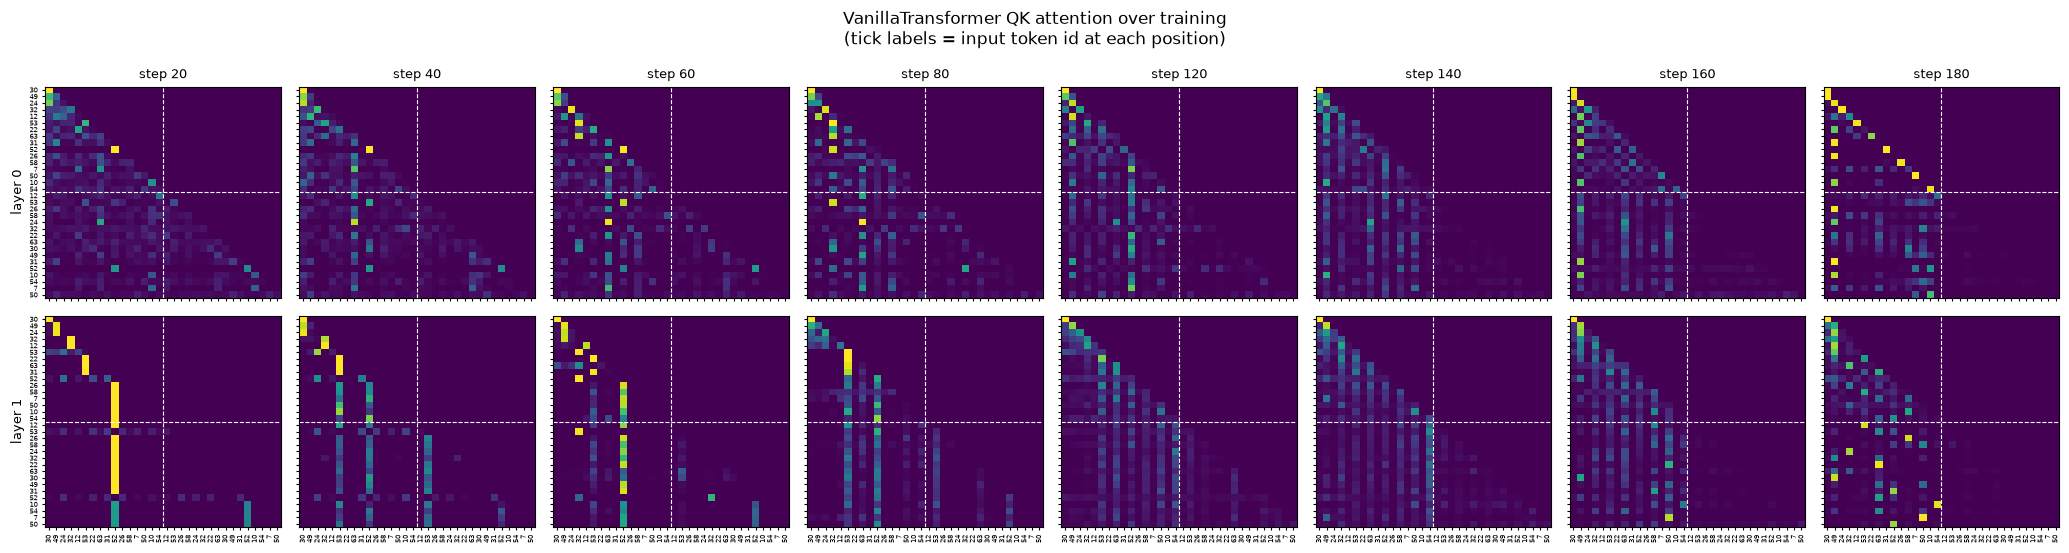

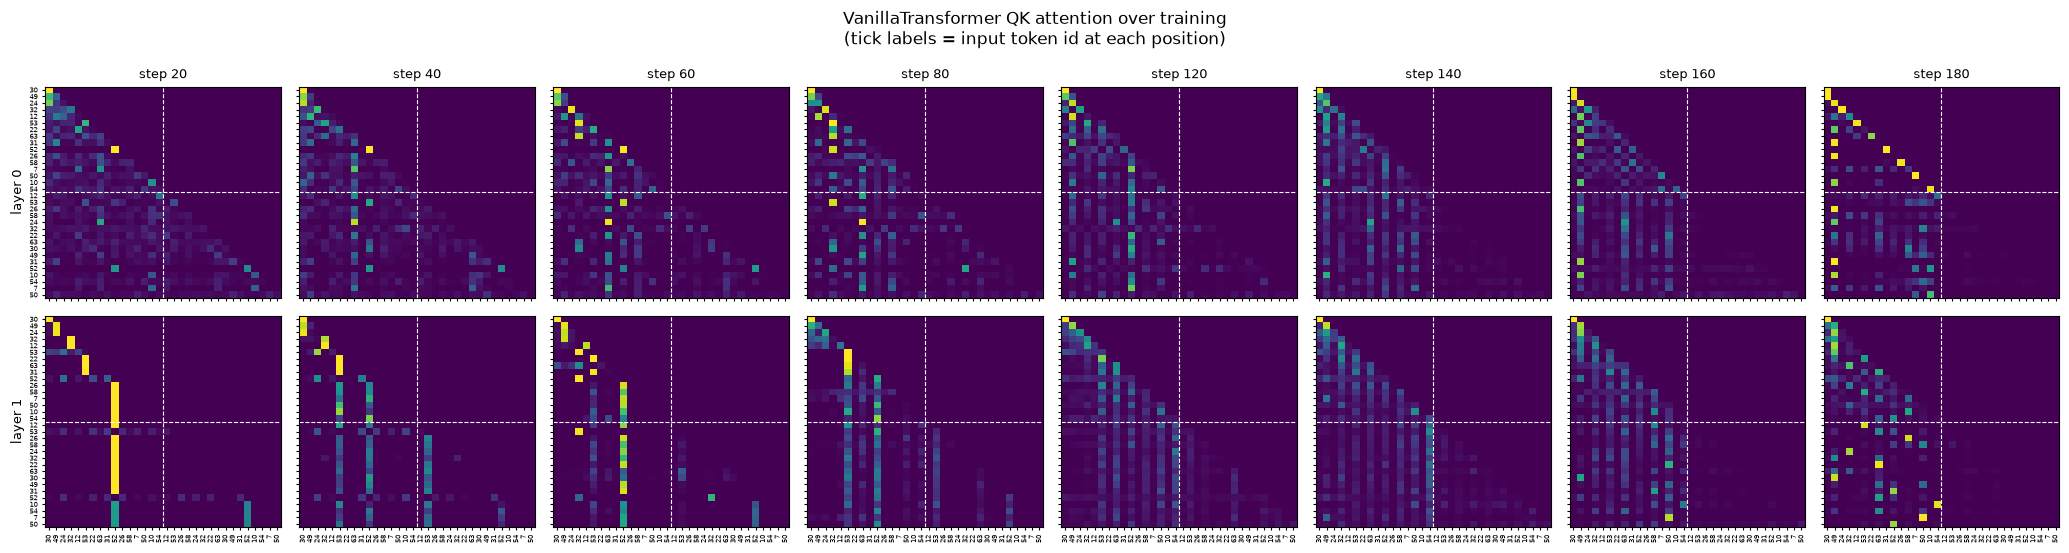

In [65]:
fig_vanilla_attn = checkpoint_attn_grid(
    vanilla, hist_vanilla["checkpoints"], example_seq, "VanillaTransformer QK attention over training"
)
fig_vanilla_attn


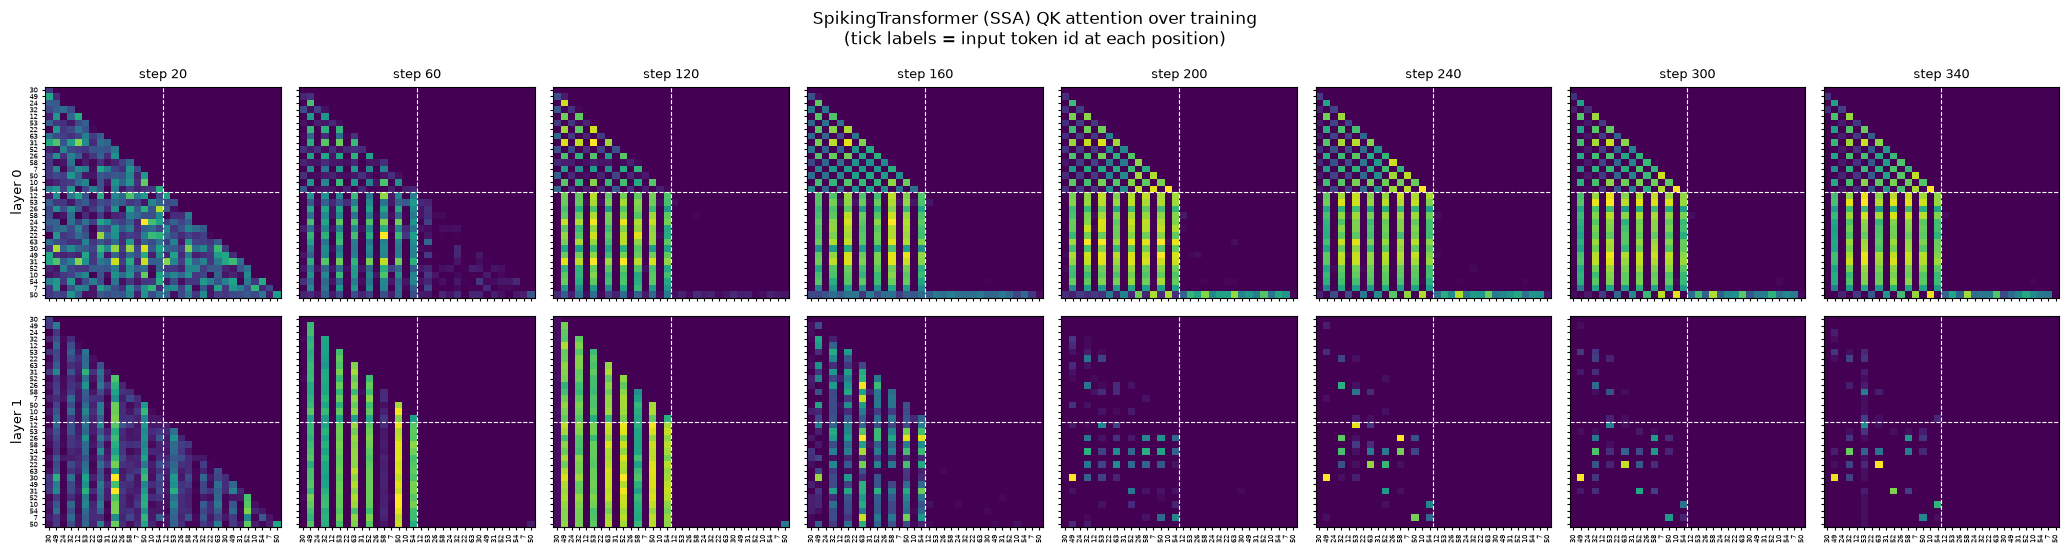

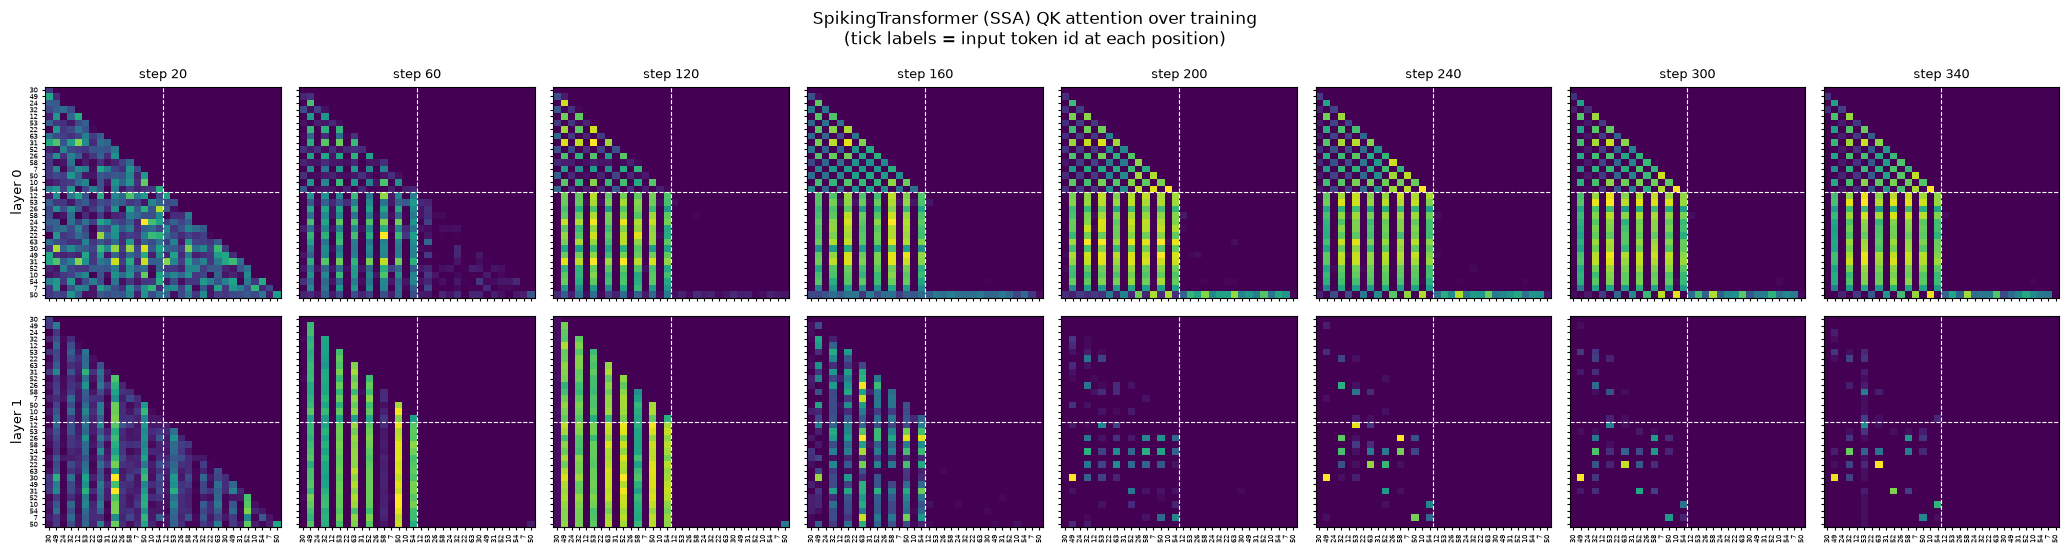

In [66]:
fig_spiking_attn = checkpoint_attn_grid(
    spiking, hist_spiking["checkpoints"], example_seq, "SpikingTransformer (SSA) QK attention over training"
)
fig_spiking_attn


## Example test output

Using the final trained weights, show the key-value pairs, the query, and both models'
predictions at every answerable (key, round >= 2) position.

In [67]:
seq = example_seq  # reuse the same example used for the attention heatmaps above

vanilla.eval()
spiking.eval()
with torch.no_grad():
    pred_vanilla = vanilla(seq)[:, :-1, :].argmax(-1)[0]
    pred_spiking = spiking(seq)[:, :-1, :].argmax(-1)[0]

tokens = seq[0].cpu().tolist()
targets = seq[0, 1:].cpu().tolist()
mask_cpu = mask.cpu().tolist()

print("full sequence:", tokens)
print()
for r in range(num_rounds):
    round_tokens = tokens[r * 2 * num_kv_pairs:(r + 1) * 2 * num_kv_pairs]
    pairs = [f"{round_tokens[j]}->{round_tokens[j+1]}" for j in range(0, len(round_tokens), 2)]
    print(f"round {r + 1}: {', '.join(pairs)}")
print()

print(f"{'pos':>4} {'key':>4} {'target(value)':>14} {'vanilla':>8} {'spiking':>8}")
for t in range(len(targets)):
    if not mask_cpu[t]:
        continue
    key_tok = tokens[t]
    truth = targets[t]
    pv = pred_vanilla[t].item()
    ps = pred_spiking[t].item()
    print(f"{t:>4} {key_tok:>4} {truth:>14} {pv:>5} ({'OK' if pv == truth else 'X'}) "
          f"{ps:>5} ({'OK' if ps == truth else 'X'})")


full sequence: [30, 49, 24, 32, 12, 53, 22, 63, 31, 52, 26, 58, 7, 50, 10, 54, 12, 53, 26, 58, 24, 32, 22, 63, 30, 49, 31, 52, 10, 54, 7, 50]

round 1: 30->49, 24->32, 12->53, 22->63, 31->52, 26->58, 7->50, 10->54
round 2: 12->53, 26->58, 24->32, 22->63, 30->49, 31->52, 10->54, 7->50

 pos  key  target(value)  vanilla  spiking
  16   12             53    53 (OK)    53 (OK)
  18   26             58    58 (OK)    58 (OK)
  20   24             32    32 (OK)    32 (OK)
  22   22             63    63 (OK)    63 (OK)
  24   30             49    49 (OK)    49 (OK)
  26   31             52    52 (OK)    52 (OK)
  28   10             54    54 (OK)    54 (OK)
  30    7             50    50 (OK)    50 (OK)
